### **Import libraries and load data**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import xgboost as xgb
from typing import List

In [2]:
# load pandas dataframe
df = pd.read_csv('resume_shortlister_dataset.csv')
df.head()

,candidate_id,skills,experience_years,job_role,shortlisted
0,C00001,"Kubernetes, Linux, Docker",5.0,DevOps Engineer,1
1,C00002,"TensorFlow, Statistics, Pandas",2.3,Data Scientist,1
2,C00003,"Pandas, TensorFlow, SQL, Statistics, Machine L...",1.9,Data Scientist,0
3,C00004,"Machine Learning, Pandas, Statistics, TensorFlow",1.1,Data Scientist,0
4,C00005,"SQL, Microservices",9.2,Backend Developer,0


### **Data cleaning and OHE**

In [3]:
# split the skills and turn the column values into list
df['skills'] = df['skills'].apply(lambda x: [skill.strip() for skill in x.split(',')])
all_skills = sorted(set(skill for skills in df['skills'] for skill in skills))

# loop for making skills individual binary columns
for skill in all_skills:
    df[skill] = df['skills'].apply(lambda x: 1 if skill in x else 0)

# drop skills column
df = df.drop(['candidate_id', 'skills'], axis = 1)

# one hot encode job role
df = pd.get_dummies(df, columns=['job_role'])

df.head()

,experience_years,shortlisted,AWS,CI/CD,CSS,Dart,Docker,Firebase,Flutter,HTML,...,Statistics,Swift,TensorFlow,Terraform,TypeScript,job_role_Backend Developer,job_role_Data Scientist,job_role_DevOps Engineer,job_role_Frontend Developer,job_role_Mobile Developer
0,5.0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,False,False,True,False,False
1,2.3,1,0,0,0,0,0,0,0,0,...,1,0,1,0,0,False,True,False,False,False
2,1.9,0,0,0,0,0,0,0,0,0,...,1,0,1,0,0,False,True,False,False,False
3,1.1,0,0,0,0,0,0,0,0,0,...,1,0,1,0,0,False,True,False,False,False
4,9.2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,True,False,False,False,False


### **Visualizations**

C:\Users\Sauja\AppData\Local\Temp\ipykernel_15332\3631388198.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = skill_counts.values, y = skill_counts.index, palette = 'viridis')


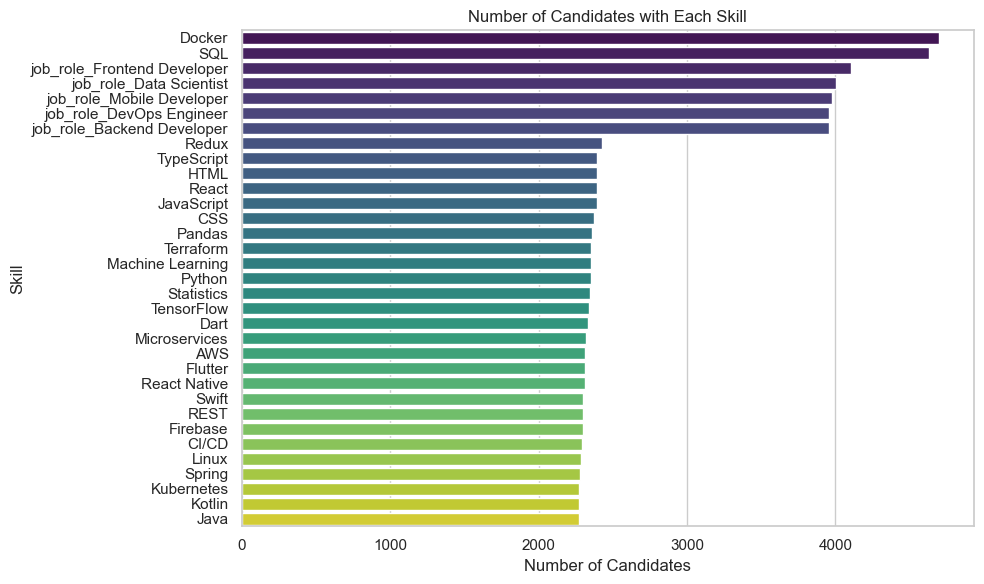

In [4]:
# set stsyle
sns.set(style = "whitegrid")

# sum skill columns
skill_columns = [col for col in df.columns if col not in ['candidate_id', 'skills', 'experience_years', 'job_role', 'shortlisted']]
skill_counts = df[skill_columns].sum().sort_values(ascending = False)

# bar plot
plt.figure(figsize = (10, 6))
sns.barplot(x = skill_counts.values, y = skill_counts.index, palette = 'viridis')
plt.title('Number of Candidates with Each Skill')
plt.xlabel('Number of Candidates')
plt.ylabel('Skill')
plt.tight_layout()
plt.show()

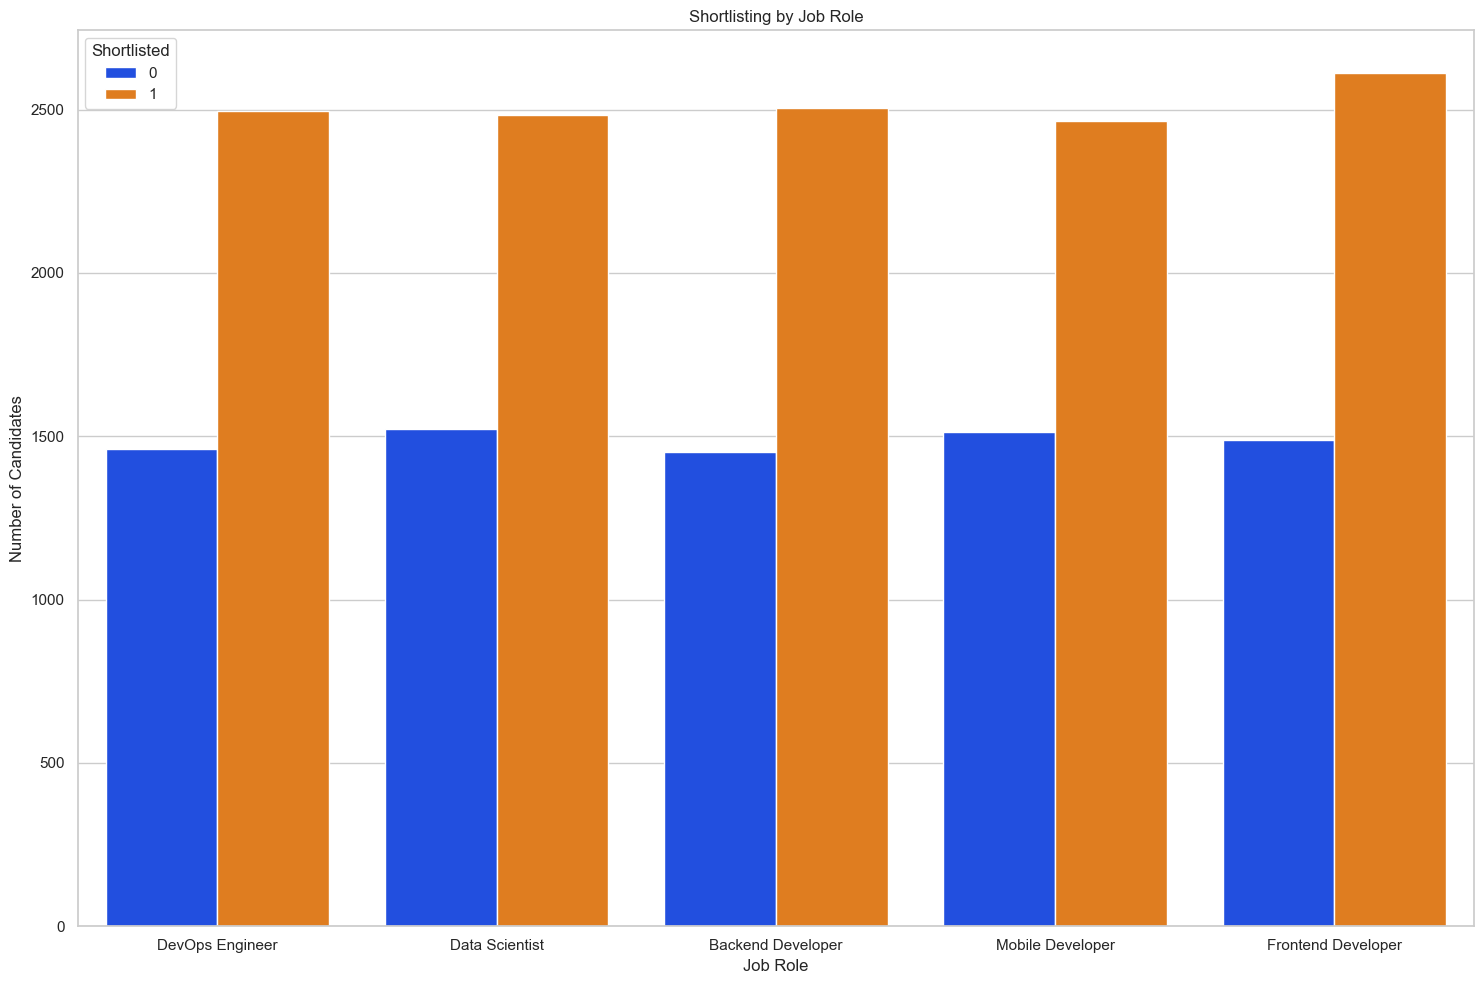

In [5]:
# Create 'job_role' column from one-hot encoded columns
job_role_columns = ['job_role_Backend Developer', 'job_role_Data Scientist',
                    'job_role_DevOps Engineer', 'job_role_Frontend Developer',
                    'job_role_Mobile Developer']

# Use idxmax to find the column name where the value is 1
df['job_role'] = df[job_role_columns].idxmax(axis=1)

# Now clean it to remove 'job_role_' prefix
df['job_role'] = df['job_role'].str.replace('job_role_', '')

# Now plot
plt.figure(figsize=(15, 10)) 
sns.countplot(data = df, x = 'job_role', hue = 'shortlisted', palette = 'bright')
plt.title('Shortlisting by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Number of Candidates')
plt.legend(title = 'Shortlisted')
plt.tight_layout()
plt.show()


C:\Users\Sauja\AppData\Local\Temp\ipykernel_15332\3272938221.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = 'shortlisted', y = 'experience_years', palette = 'dark', width = 0.35)


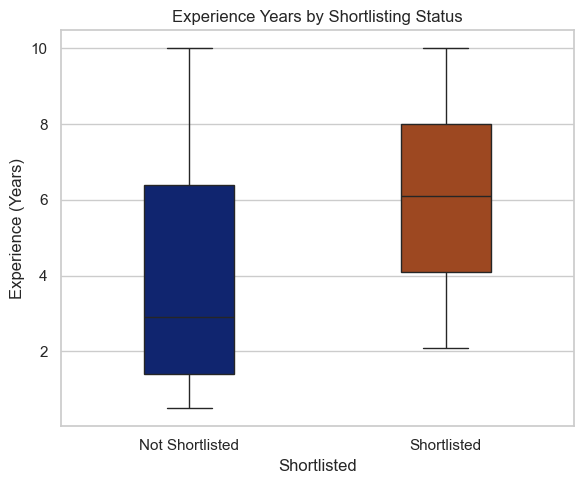

In [6]:
# boxplot of experience by shortlisted status
plt.figure(figsize=(6, 5))
sns.boxplot(data = df, x = 'shortlisted', y = 'experience_years', palette = 'dark', width = 0.35)
plt.xticks([0, 1], ['Not Shortlisted', 'Shortlisted'])
plt.title('Experience Years by Shortlisting Status')
plt.xlabel('Shortlisted')
plt.ylabel('Experience (Years)')
plt.tight_layout()
plt.show()

### **Train test split**

In [7]:
# dependent and independent variables
X = df.drop('shortlisted', axis = 1)
y = df['shortlisted']
print(f'X shape: {X.shape} y shape: {y.shape}')
# split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X shape: (20000, 35) y shape: (20000,)


### **Model Training and Metrics**

In [8]:
X_train = X_train.drop(columns=['job_role'])
X_test = X_test.drop(columns=['job_role'])
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)


C:\Users\Sauja\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [23:18:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [9]:
# metrics
y_pred = model.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[1486    0]
 [   0 2514]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1486
           1       1.00      1.00      1.00      2514

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



C:\Users\Sauja\AppData\Local\Temp\ipykernel_15332\702775288.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'Importance', y = 'Feature', data = importance_df, palette = 'viridis')
C:\Users\Sauja\AppData\Local\Temp\ipykernel_15332\702775288.py:15: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Sauja\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


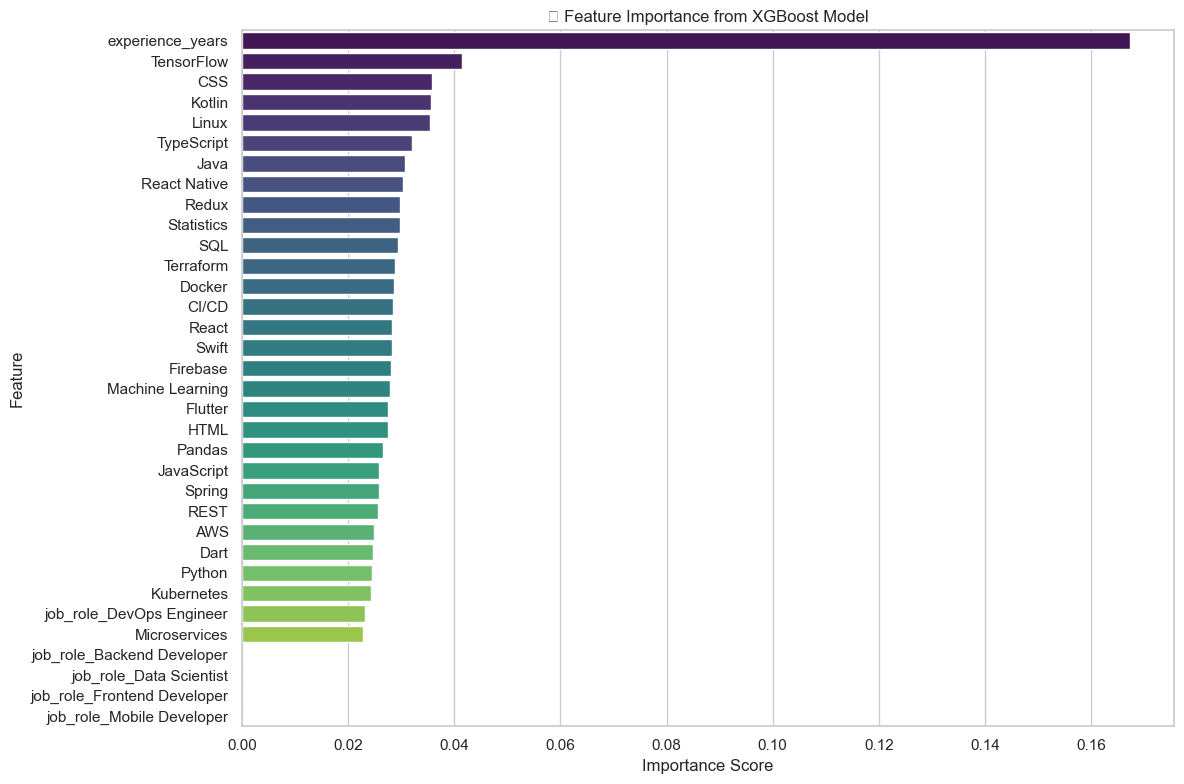

In [10]:
# feature importance
importances = model.feature_importances_
features = X_train.columns   # <-- Fix here

# df for plotting
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by = 'Importance', ascending = False)

# plot using sns
plt.figure(figsize = (12, 8))
sns.barplot(x = 'Importance', y = 'Feature', data = importance_df, palette = 'viridis')
plt.title('🔍 Feature Importance from XGBoost Model')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [11]:
model.save_model("xgboost_model.json")


### **Prediction on unseen data**

In [12]:
# predict
def predict_shortlist(input_dict: dict, all_features: List[str], saved_model: str = 'xgboost_model.json') -> (int, float):
    # load model
    model = XGBClassifier()
    model.load_model(saved_model)
    # create a df to feed to the model
    inputs = pd.DataFrame([input_dict])
    inputs = inputs.reindex(columns = all_features, fill_value = 0)
    # get prediction and probability
    pred = model.predict(inputs)[0]
    proba = model.predict_proba(inputs)[0][1]
    return pred, proba

In [13]:
# example input (based on your processed features)
candidate_input = {
    "experience_years": 2.5,
    "TensorFlow": 1,
    "Pandas": 1,
    "SQL": 0,
    "Linux": 0,
    "Docker": 1,
    "DevOps Engineer": 0,
    "Data Scientist": 1,
    "Backend Developer": 0
}

# get all feature names from your trained data
all_features = X_train.columns.tolist()  # ⚡ use X_train.columns, not X.columns

model_path = 'xgboost_model.json'   # ⚡ corrected path

# predict
prediction, probability = predict_shortlist(candidate_input, all_features, model_path)
print(f"Shortlisted? {'Yes' if prediction == 1 else 'No'}, with probability of {probability if prediction == 1 else 1 - probability:.2f}")


Shortlisted? No, with probability of 0.99
